# Simulação

## Metodologia

O sinal será gerado com alta densidade temporal e quantizado separadamente com 3, 4 e 8 bits. Para cada caso serão calculados os níveis, a resolução e medidas do erro. Os gráficos apresentarão o sinal original e o quantizado, além do erro ao longo do tempo.

## Bibliotecas

* NumPy – operações numéricas e geração do sinal.  
* Matplotlib – gráficos.  
* Seaborn – apresentação visual.  
* Pandas – organização dos resultados.

## Implementação

Apresentar o código-fonte utilizado na simulação.

**Código da simulação:**

In [2]:
# ============================================================
# IMPORTAÇÕES
# ============================================================
import numpy as np  
import matplotlib.pyplot as plt  
import seaborn as sns  
import pandas as pd

# ============================================================  
# CONFIGURAÇÕES  
# ============================================================

sns.set_theme(style="whitegrid", context="notebook")

In [3]:
# Parâmetros do sinal
A = 0.5
offset = 0.5
f0 = 5
T = 1

# Tensão de referência
Vref = 1.0

# Quantidades de bits analisadas
bits_values = [3, 4, 8]

# Eixo de tempo
t = np.linspace(0, T, 5000)

# ============================================================
# SINAL ORIGINAL
# ============================================================

x = offset + A * np.sin(2 * np.pi * f0 * t)

# ============================================================
# RESULTADOS
# ============================================================

resultados = []

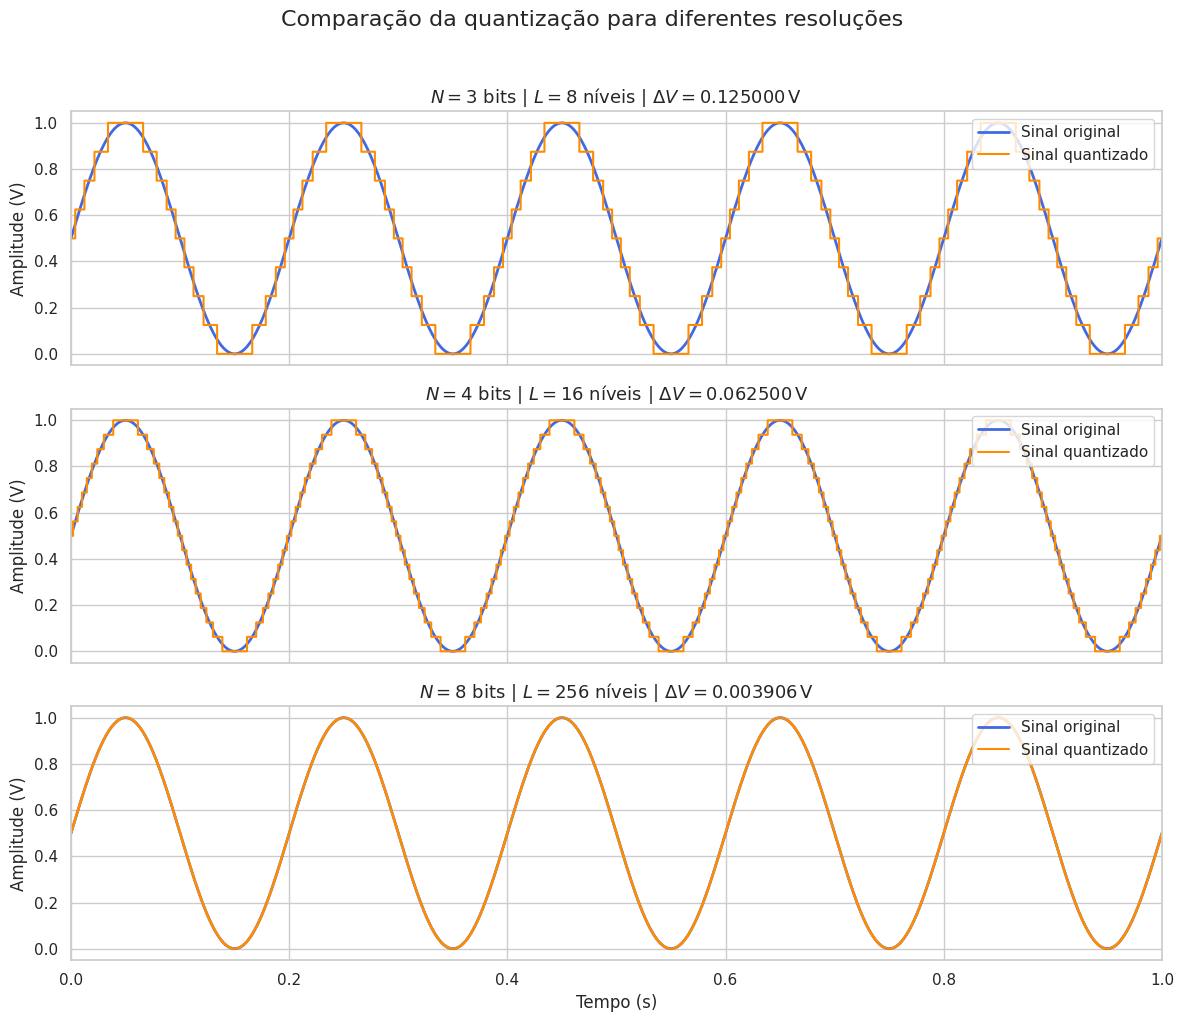


Resultados da quantização:
 Bits  Níveis  Resolução (V)  Erro máximo (V)  Erro RMS (V)  Erro médio absoluto (V)
    3       8       0.125000         0.062446      0.033885                 0.028111
    4      16       0.062500         0.031244      0.017269                 0.014512
    8     256       0.003906         0.001953      0.001115                 0.000959


In [4]:
# ============================================================
# COMPARAÇÃO DOS TRÊS CASOS
# ============================================================

fig, axes = plt.subplots(
    len(bits_values),
    1,
    figsize=(12, 10),
    sharex=True
)

for ax, N in zip(axes, bits_values):

    L = 2**N
    delta_V = Vref / (2**N)

    # Quantização
    xq = np.round(x / delta_V) * delta_V
    xq = np.clip(xq, 0, Vref)

    # Erro
    erro = x - xq
    erro_max = np.max(np.abs(erro))
    erro_rms = np.sqrt(np.mean(erro**2))
    erro_medio = np.mean(np.abs(erro))

    # Sinal original
    sns.lineplot(
        x=t,
        y=x,
        ax=ax,
        color="royalblue",
        linewidth=2,
        label="Sinal original"
    )

    # Sinal quantizado
    ax.step(
        t,
        xq,
        where="mid",
        color="darkorange",
        linewidth=1.5,
        label="Sinal quantizado"
    )

    ax.set_title(
        rf"$N = {N}$ bits"
        rf" | $L = {L}$ níveis"
        rf" | $\Delta V = {delta_V:.6f}\,\mathrm{{V}}$",
        fontsize=13
    )

    ax.set_ylabel("Amplitude (V)")
    ax.set_ylim(-0.05, 1.05)
    ax.legend(loc="upper right")

    resultados.append({
        "Bits": N,
        "Níveis": L,
        "Resolução (V)": delta_V,
        "Erro máximo (V)": erro_max,
        "Erro RMS (V)": erro_rms,
        "Erro médio absoluto (V)": erro_medio
    })

axes[-1].set_xlabel("Tempo (s)")

fig.suptitle(
    "Comparação da quantização para diferentes resoluções",
    fontsize=16,
    y=1.02
)

plt.xlim(0, T)
plt.tight_layout()
plt.show()

# ============================================================
# TABELA DE RESULTADOS
# ============================================================

df_resultados = pd.DataFrame(resultados)

print("\nResultados da quantização:")
print(df_resultados.to_string(index=False))